In [1]:
from scipy import constants as const
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# constants
e = const.e
hbar = const.hbar
eps_0 = const.epsilon_0
m_e = const.m_e
pi = const.pi
a = 4 * pi * eps_0 * hbar**2 / m_e / e**2
print(a)

# define the potential
def V(r, l):
    alpha = e**2 / (4 * pi * eps_0)
    beta = (hbar**2 / 2 / m_e) * l * (l+1)
    return -alpha / r + beta / r**2

# Define function for Simpson's rule
def Simpson(psi, a, b, n):
    if n % 2 == 0:
        print('Error: n must be an odd number!')
    else:
        h = (b-a)/(n-1)
        x = np.linspace(a,b,n)

        # Create array of c_i
        c = np.ones(n)
        for i in range(len(c)):
            if i % 2 == 0:
                c[i] = 2
            else:
                c[i] = 4
        c[0], c[-1] = 1, 1

        contribution = (h/3)*c*psi
        return np.sum(contribution)

5.291772105443463e-11


In [22]:
# create a function for plotting the actul results
def Actual_Radial_Func(r,n,l):
    expo = np.exp(-r/(n*a))
    if n == 1:
        return 2 * a**(-1.5) * expo
    if n == 2:
        if l == 0:
            poly = 1 - r / (2*a)
            return (1/np.sqrt(2)) * a**(-1.5) * poly * expo
    if n==3:
        if l == 1: 
            const = 8 * a**(-1.5) / (27*np.sqrt(6))
            poly = (1 - r / (6*a)) * (r/a)
            return const * poly * expo
        if l==2:
            const = 4 * (a**-1.5) / (81 * np.sqrt(30))
            poly = (r/a)**2
            return const * poly * expo

In [23]:
# quantum numbers
l = 0

# discretize the r-grid
r_i = 0
r_f = 100*a
n = 1001
dx = (r_f-r_i) / (n-1)
k = hbar**2 / (2 * m_e * dx**2)

r = np.linspace(r_i,r_f,n)
r_plot = r[1:-1] # r array with first and last elements removed

def Solve(l=0):
    '''
    function that will solve the Hamiltonian eigenvalue problem, 
    normalize the eigenvectors, and return the energies and normalized
    vectors
    '''
    # build the hamiltonian matrix
    H = np.zeros((n-2,n-2))
    
    H[0][0] = 2*k + V(r[1],l)
    H[0][1] = -k
    
    H[-1][-2]= -k
    H[-1][-1]= 2*k + V(r[n-2],l)
    
    for ii in range(1,n-3):
        H[ii][ii] = 2*k + V(r[ii+1],l)
        H[ii][ii+1] = -k
        H[ii][ii-1] = -k

    # solve the Hamiltonian eigenenergies and vectors
    vals, vecs = np.linalg.eigh(H)
    energies = vals[0:3]/e # return the first three energies in eV

    # add in the boundary conditions to the first three vectors
    wavefuncs = np.zeros((n-2,3))
    wavefuncs = vecs[:,0:3]
    
    # return the first three energies and vectors
    return energies, wavefuncs

# define a function that will create and normalize the actual radial wavefunction from u
def Normalization(u):
    ret_psi = np.zeros((n,3))
    for i in range(3):
        # create the radial function from u
        ret_psi[1:-1,i] = u[:,i] # / r_plot
    
        # normalize the wavefunction
        I = Simpson(ret_psi[:,i]**2,r_i,r_f,n)
        c = 1 / np.sqrt(I)
        ret_psi[:,i] = c * ret_psi[:,i]
    
        #add boundary conditions: 0 at r=0 and r->inf
        ret_psi[1:-1,i] = ret_psi[1:-1,i] / r_plot
    return ret_psi

Text(0, 0.5, '$V_{eff}(r)$')

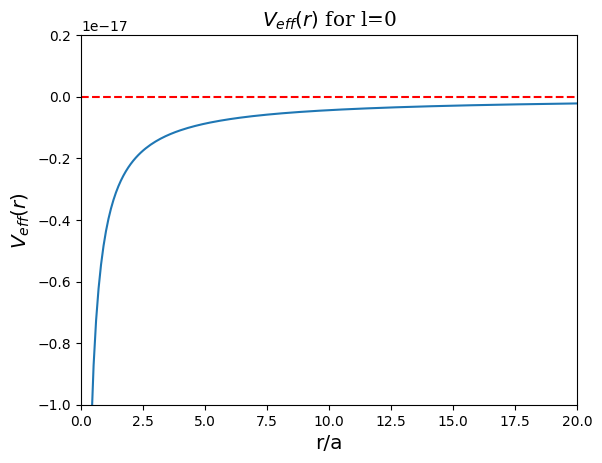

In [24]:
# Plot of the effective potential for l=0
plt.plot(r_plot/a,V(r_plot,0))
plt.axhline(y=0,ls='--',c='r')
plt.xlim(0,20)
plt.ylim(-1e-17,0.2e-17)
plt.title('$V_{eff}(r)$ for l=0',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel('$V_{eff}(r)$',fontsize='x-large')
# plt.savefig('Veff l0.jpg',bbox_inches='tight')

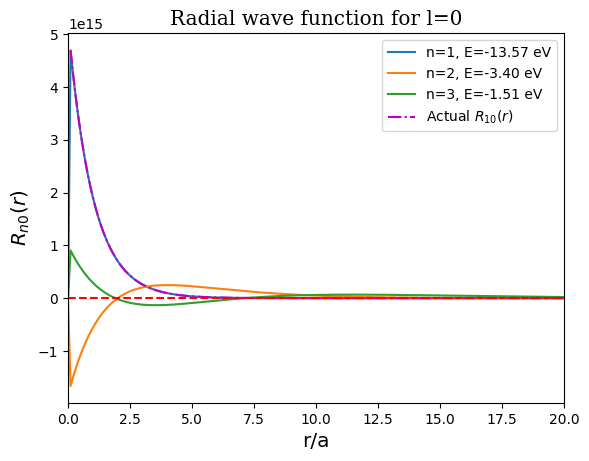

In [45]:
# Solve for the eigenenergies and vectors for l = 0
energies, psis_0 = Solve()
norm_radial_0 = Normalization(psis_0)
for i in range(3):
    plt.plot(r/a,-norm_radial_0[:,i],label=f'n={i+1}, E={energies[i]:.2f} eV')
plt.plot(r_plot/a,Actual_Radial_Func(r_plot,1,0),label='Actual $R_{10}(r)$',ls='-.',c='m')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,20)
plt.title('Radial wave function for l=0',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$R_{n0}(r)$',fontsize='x-large')
plt.savefig('Radial Wave Func l0',bbox_inches='tight')

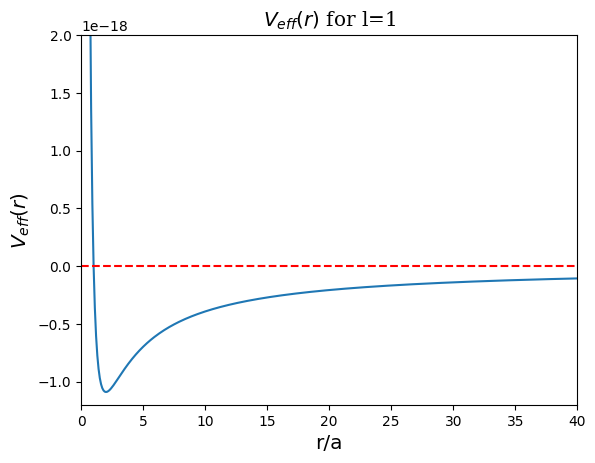

In [38]:
# Plot of the effective potential for l=1
plt.plot(r_plot/a,V(r_plot,1))
plt.axhline(y=0,ls='--',c='r')
plt.xlim(0,40)
plt.ylim(-0.12e-17,0.2e-17)
plt.title('$V_{eff}(r)$ for l=1',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel('$V_{eff}(r)$',fontsize='x-large')
plt.savefig('Veff l1',bbox_inches='tight')

In [27]:
#  l = 1
energies_1, psis_1 = Solve(l=1)
norm_radial_1 = Normalization(psis_1)

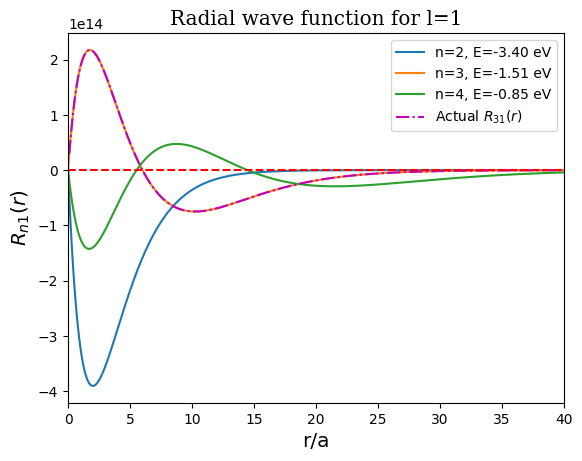

In [32]:
for i in range(3):
    plt.plot(r/a,norm_radial_1[:,i],label=f'n={i+2}, E={energies_1[i]:.2f} eV')
plt.plot(r_plot/a,Actual_Radial_Func(r_plot,3,1),label='Actual $R_{31}(r)$',ls='-.',c='m')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,40)
plt.title('Radial wave function for l=1',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$R_{n1}(r)$',fontsize='x-large')
plt.savefig('Radial wave func l1',bbox_inches='tight')

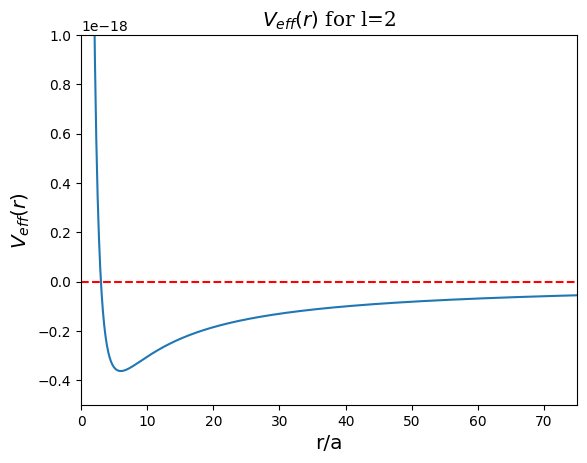

In [33]:
# Plot of the effective potential for l=2
plt.plot(r_plot/a,V(r_plot,2))
plt.axhline(y=0,ls='--',c='r')
plt.xlim(0,75)
plt.ylim(-0.05e-17,0.1e-17)
plt.title('$V_{eff}(r)$ for l=2',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel('$V_{eff}(r)$',fontsize='x-large')
# plt.savefig('Veff l2',bbox_inches='tight')

In [34]:
# l = 2
energies_2, psis_2 = Solve(l=2)
norm_radial_2 = Normalization(psis_2)

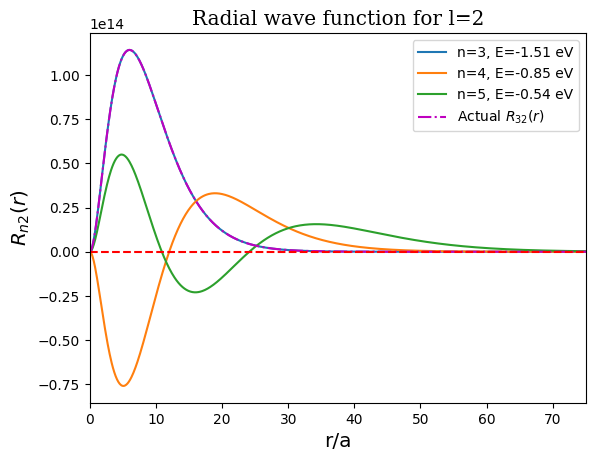

In [37]:
for i in range(3):
    plt.plot(r/a,-norm_radial_2[:,i],label=f'n={i+3}, E={energies_2[i]:.2f} eV')
plt.plot(r_plot/a,Actual_Radial_Func(r_plot,3,2),label='Actual $R_{32}(r)$',ls='-.',c='m')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,75)
plt.title('Radial wave function for l=2',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$R_{n2}(r)$',fontsize='x-large')
plt.savefig('Radial wave func l2',bbox_inches='tight')

## Plotting the square of the wave function

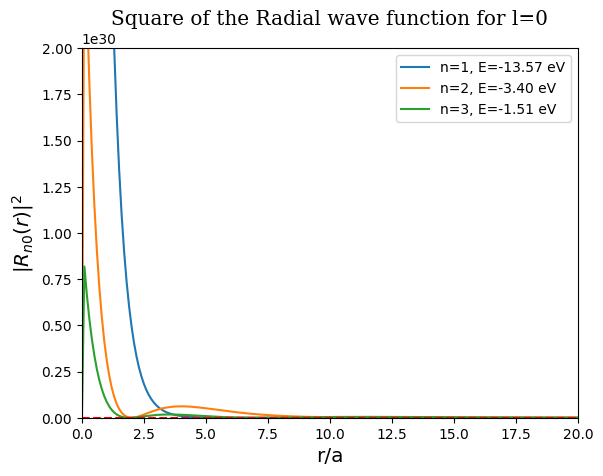

In [43]:
# l = 0
for i in range(3):
    plt.plot(r/a,norm_radial_0[:,i]**2,label=f'n={i+1}, E={energies[i]:.2f} eV')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,20)
plt.ylim(0,0.2e31)
plt.title('Square of the Radial wave function for l=0',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$|R_{n0}(r)|^2$',fontsize='x-large')
plt.savefig('Square Radial func l0',bbox_inches='tight')

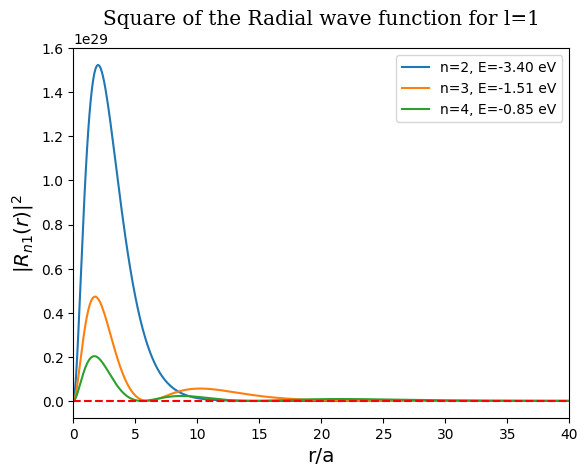

In [40]:
# l = 0
for i in range(3):
    plt.plot(r/a,norm_radial_1[:,i]**2,label=f'n={i+2}, E={energies_1[i]:.2f} eV')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,40)
plt.title('Square of the Radial wave function for l=1',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$|R_{n1}(r)|^2$',fontsize='x-large')
plt.savefig('square radial func l1',bbox_inches='tight')

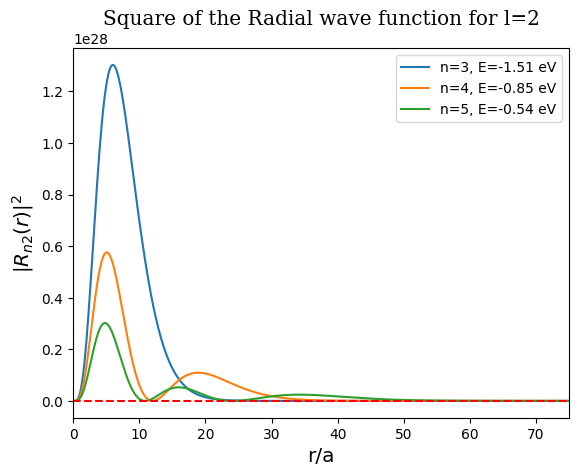

In [41]:
# l = 2
for i in range(3):
    plt.plot(r/a,norm_radial_2[:,i]**2,label=f'n={i+3}, E={energies_2[i]:.2f} eV')
plt.legend()
plt.axhline(y=0, ls='--', c='r')
plt.xlim(0,75)
plt.title('Square of the Radial wave function for l=2',family='serif',fontsize='x-large')
plt.xlabel('r/a',fontsize='x-large')
plt.ylabel(r'$|R_{n2}(r)|^2$',fontsize='x-large')
plt.savefig('Square radial func l2',bbox_inches='tight')

# Angular part

(361, 1001)
[[0.3862742  0.3862742  0.3862742  ... 0.3862742  0.3862742  0.3862742 ]
 [0.38603889 0.38603889 0.38603889 ... 0.38603889 0.38603889 0.38603889]
 [0.38533326 0.38533326 0.38533326 ... 0.38533326 0.38533326 0.38533326]
 ...
 [0.38533326 0.38533326 0.38533326 ... 0.38533326 0.38533326 0.38533326]
 [0.38603889 0.38603889 0.38603889 ... 0.38603889 0.38603889 0.38603889]
 [0.3862742  0.3862742  0.3862742  ... 0.3862742  0.3862742  0.3862742 ]]
(361, 1001)


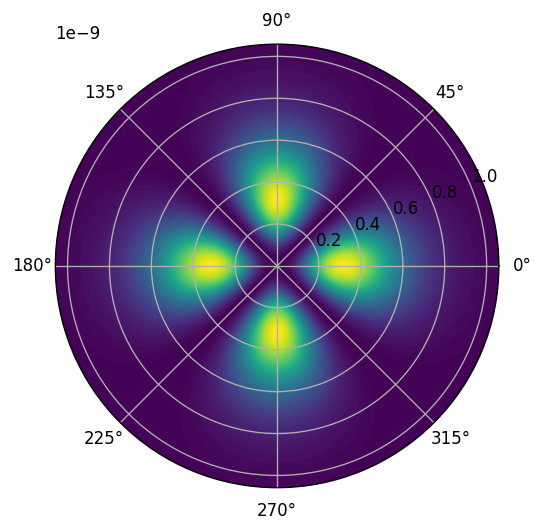

In [46]:
def Y_22(phi):
    return np.sqrt(15/(32*pi)) * np.cos(2*phi)

rlist = np.linspace(0,20*a,n)
philist = np.radians(np.arange(0,361,1))
rmesh,phimesh = np.meshgrid(rlist,philist)
print(phimesh.shape)
print(Y_22(phimesh))

Psi_322 = Actual_Radial_Func(rmesh,3,2) * Y_22(phimesh)
print(Psi_322.shape)

fig,ax = plt.subplots(dpi=120,subplot_kw=dict(projection='polar'))
ax.contourf(phimesh,rmesh,Psi_322**2,100)

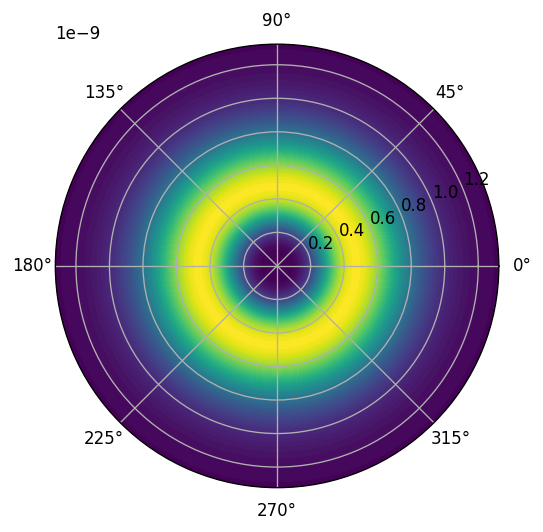

In [47]:
final_n = 250
rlist = np.linspace(0,25*a,final_n)
philist = np.radians(np.arange(0,361,1))
rmesh,phimesh = np.meshgrid(rlist,philist)
R_30 = psis_2[:final_n,0]

R_matrix = np.zeros((361,final_n))
for i in range(361):
    R_matrix[i,:] = R_30

fig,ax = plt.subplots(dpi=120,subplot_kw=dict(projection='polar'))
ax.contourf(phimesh,rmesh,R_matrix**2,100)
# ok that's what I expect to see now baby

In [48]:
# make the function for the angular functions
def Angular_Functions(phi,l,m):
    if l == 0:
        const = np.sqrt(1/(4*pi))
        return const
    if l == 1:
        if m == 0:
            const = np.sqrt(3/(4*pi))
            return const
        else:
            const = np.sqrt(3/(8*pi))
            if m == 1:
                return -const * np.cos(phi)
            if m == -1:
                return const * np.cos(phi)
    if l == 2:
        if m == 0:
            return 2 * np.sqrt(5/(16*pi))
        elif abs(m) == 1:
            const = np.sqrt(15/(8*pi))
        elif abs(m) == 2:
            return np.sqrt(15/(32*pi)) * np.cos(2*phi)

In [99]:
def Plot_Orbital(R,n_quant,l,m,j):
    # create rmesh and phi mesh
    k = 100 / j
    n_f = int(np.ceil(n/k))
    rlist = np.linspace(0,j*a,n_f)
    philist = np.radians(np.arange(0,361,1))
    rmesh,phimesh = np.meshgrid(rlist,philist)

    # create R matrix to be used in Psi_nlm
    R_plot = R[:n_f]
    R_matrix = np.zeros((361,n_f))
    for i in range(361):
        R_matrix[i,:] = R_plot

    # create Y_lm to be multiplied by R_nl Y(phimesh)
    Y_lm = Angular_Functions(phimesh,l,m)

    # multily R_nl and Y_lm to create Psi_nlm
    Psi = R_matrix * Y_lm
    ProbAmp = Psi**2

    # create the plot
    upper_lim = np.percentile(ProbAmp,95)
    fig,ax = plt.subplots(dpi=120,subplot_kw=dict(projection='polar'))
    ax.contourf(phimesh,rmesh,np.clip(ProbAmp,0,upper_lim),100,cmap='magma')
    ax.axis("off")

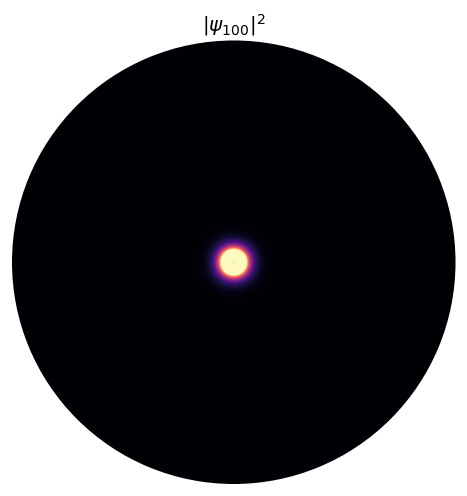

In [141]:
# 1s orbital
Plot_Orbital(norm_radial_0[:,0],1,0,0,20)
plt.title(r'$|\psi_{100}|^2$')
plt.savefig('1s.png',bbox_inches='tight')

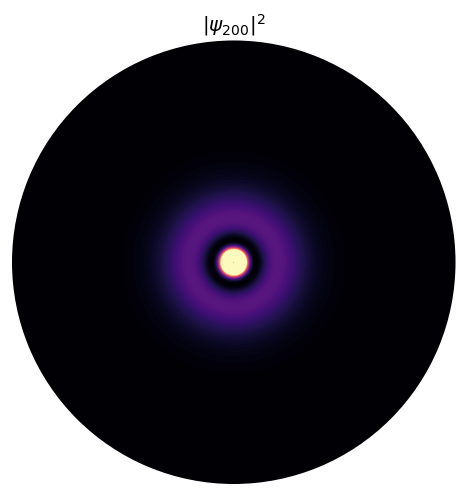

In [142]:
# 2s orbital
Plot_Orbital(norm_radial_0[:,1],2,0,0,20)
plt.title(r'$|\psi_{200}|^2$')
plt.savefig('2s.png',bbox_inches='tight')

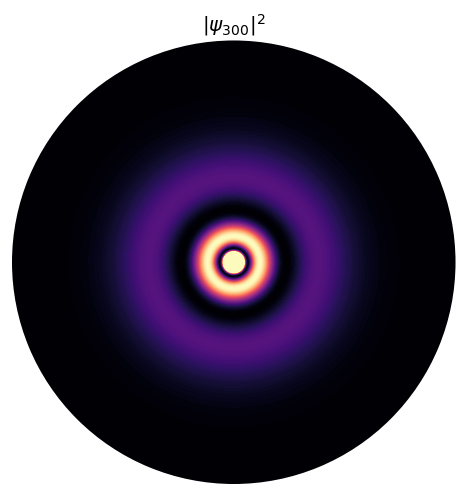

In [143]:
# 3s orbital
Plot_Orbital(norm_radial_0[:,2],3,0,0,30)
plt.title(r'$|\psi_{300}|^2$')
plt.savefig('3s.png',bbox_inches='tight')

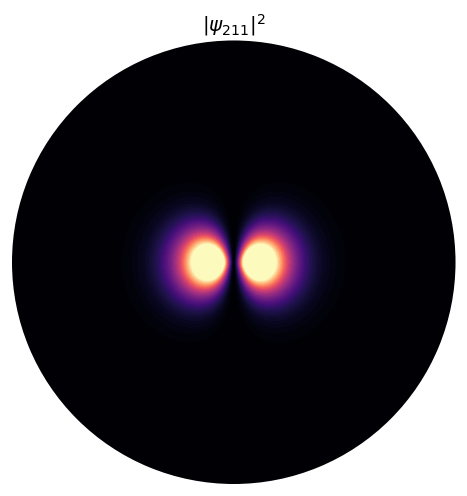

In [144]:
# 2p orbial
Plot_Orbital(norm_radial_1[:,0],2,1,1,20)
plt.title(r'$|\psi_{211}|^2$')
plt.savefig('2p.png',bbox_inches='tight')

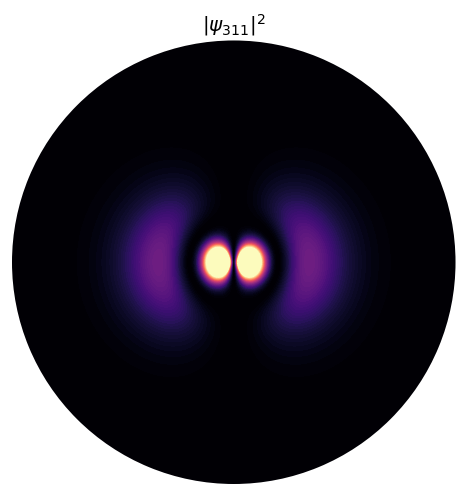

In [145]:
# 3p orbital
Plot_Orbital(norm_radial_1[:,1],3,1,1,30)
plt.title(r'$|\psi_{311}|^2$')
plt.savefig('3p.png',bbox_inches='tight')

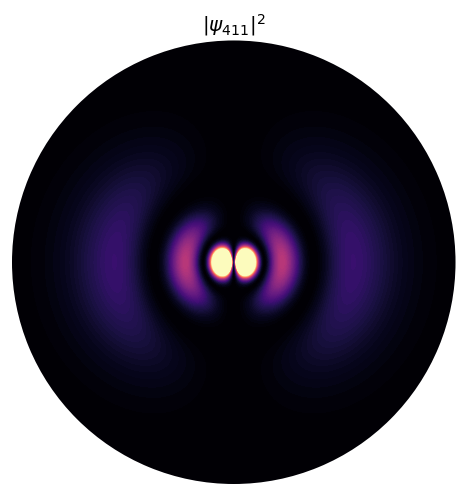

In [146]:
# 4p orbital
Plot_Orbital(norm_radial_1[:,2],4,1,1,40)
plt.title(r'$|\psi_{411}|^2$')
plt.savefig('4p.png',bbox_inches='tight')

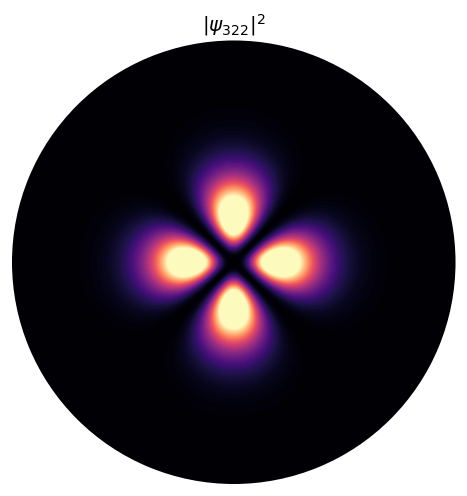

In [147]:
# 3d orbital
Plot_Orbital(norm_radial_2[:,0],3,2,2,30)
plt.title(r'$|\psi_{322}|^2$')
plt.savefig('3d.png',bbox_inches='tight')

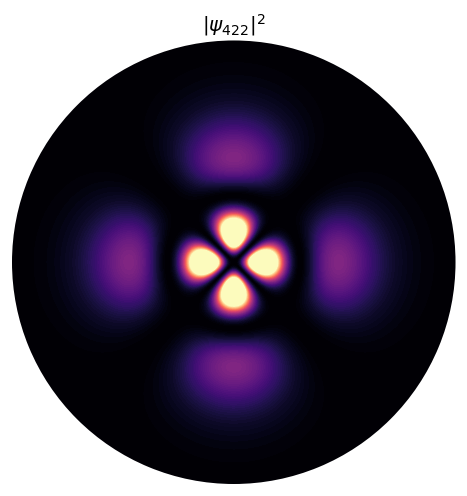

In [148]:
# 4d orbital
Plot_Orbital(norm_radial_2[:,1],2,2,2,40)
plt.title(r'$|\psi_{422}|^2$')
plt.savefig('4d.png',bbox_inches='tight')

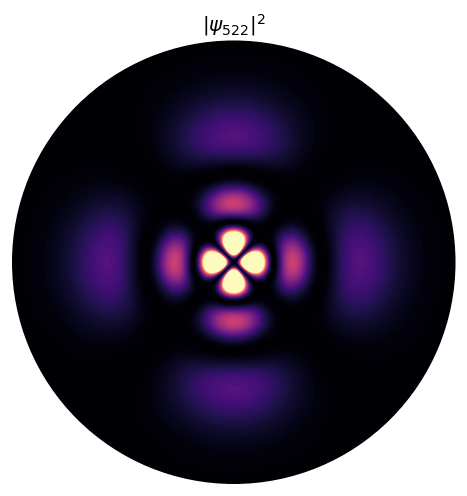

In [149]:
# 5d orbital
Plot_Orbital(norm_radial_2[:,2],3,2,2,60)
plt.title(r'$|\psi_{522}|^2$')
plt.savefig('5d.png',bbox_inches='tight')